# Swahili corpus audit: what is really in the data
**Michael · Practicum (CMU Africa) · 4 Oct 2026**

This notebook runs end to end with no uploads. It shows (1) how many passages survive each cleaning step, (2) what human review found, (3) licences and the word counts against the target, (4) a seed corpus of 10,000 words per domain, and (5) word-level punctuation and capitalisation annotation.

**Honesty box:** the main pool was screened by an AI pass, not by humans. Michael personally reviewed 100 passages (19 kept). The rules below were fitted to those labels (about 71% precision), so every estimate here is a *rule-filtered estimate*, not verified data.

In [1]:
import re, json, collections, unicodedata
import matplotlib
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (8, 3.8), "axes.spines.top": False, "axes.spines.right": False, "font.size": 11})
INK, ACCENT, TEAL, GREY = "#14202B", "#B5530F", "#1F6F78", "#9AA7B2"
D = ["agriculture", "finance", "health", "law", "telecoms"]
print("ready")

ready


## 1. Cleaning funnel

Caption filter removed 5,316 passages (266,983 words, 33% of accepted words), almost all from AfriVoice.


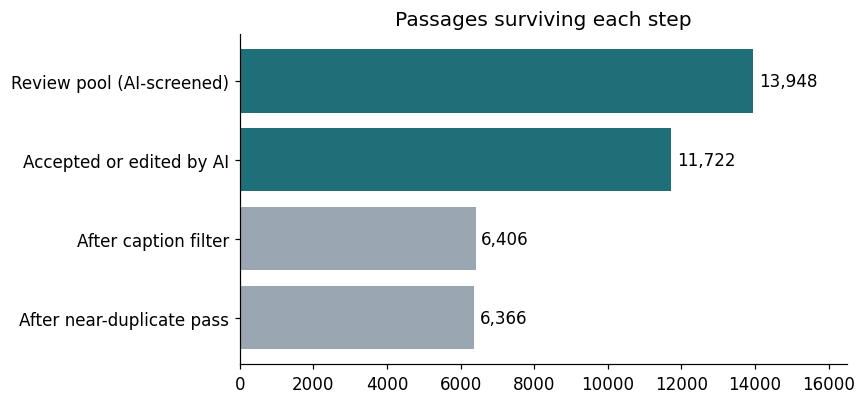

In [2]:
funnel = [("Review pool (AI-screened)", 13948), ("Accepted or edited by AI", 11722), ("After caption filter", 6406), ("After near-duplicate pass", 6366)]
fig, ax = plt.subplots()
ax.barh([f[0] for f in funnel][::-1], [f[1] for f in funnel][::-1], color=[TEAL, TEAL, GREY, GREY][::-1])
for i, f in enumerate(funnel[::-1]): ax.text(f[1] + 150, i, f"{f[1]:,}", va="center")
ax.set_xlim(0, 16500); ax.set_title("Passages surviving each step"); plt.tight_layout(); plt.show()
print("Caption filter removed 5,316 passages (266,983 words, 33% of accepted words), almost all from AfriVoice.")

## 2. The caption problem, and rules fitted to Michael's labels
Most AfriVoice 'text' is people describing a picture. Keyword labels call it agriculture or health because it contains farm or clinic words.

In [3]:
import re

# Present-participle / visual-description cues in Swahili
MARKERS = [
    r"\binaonekana\b", r"\bnaona\b", r"\btunaona\b", r"\btunayoona\b", r"\bunaona\b", r"\banaonekana\b", r"\bwanaonekana\b", r"\bzinaonekana\b",
    r"\bakiwa\b", r"\bwakiwa\b", r"\bikiwa\b", r"\bzikiwa\b", r"\bkikiwa\b", r"\bukiwa\b", r"\bwamevaa\b", r"\bamevaa\b", r"\bamevalia\b", r"\bwamevalia\b", r"\bamevaa\b", r"\bwa?mevaa\b", r"\bamevalia\b",
    r"\bpicha\b", r"\btaswira\b", r"\bmandhari\b", r"\bkwenye lebo\b", r"\bkifungashio\b", r"\bvifungashio\b", r"\bmuonekano\b",
    r"\bhii ni (?:picha|taswira)\b", r"\bhuu ni mfumo\b", r"\bhili ni (?:eneo|duka|tangazo)\b", r"\bhii ni (?:simu|mashine|chumba)\b",
    r"\brangi (?:ya|ye|za|nyekundu|nyeupe|nyeusi|ya kijani|ya bluu|ya manjano)\b",
    r"\bnyuma yake\b", r"\bupande wa kushoto\b", r"\bupande wa kulia\b", r"\bkatikati\b",
    r"\bishara kwamba\b", r"\bikionyesha\b", r"\bikionesha\b", r"\bikiashiria\b", r"\bikidokeza\b", r"\bzikionyesha\b",
]
RX = [re.compile(m, re.I) for m in MARKERS]
# Strong lead patterns that start a description
LEAD = re.compile(r"^(?:mtu|watu|mwanaume|mwanamke|mkulima|wakulima|mfanyakazi|daktari|madaktari|wauguzi|muuguzi|mashine|chupa|noti|pesa|mkono|shamba|msururu|mpangilio|sehemu|hii ni|hili ni|hapa ni|hapa nayo|ni (?:ng'ombe|mtu|moja)|katika chumba|ndani ya|mfumo wa|tunayoona|huku tunaona|kifaa hiki|pakiti|tofauti kabla|wafanya kazi|wafanyakazi|mwezeshaji|mashine mbili|kilimo cha)\b", re.I)
# Strong news/document cues that argue against a caption
NEWS = re.compile(r"\b(?:alisema|amesema|ameeleza|serikali|waziri|mheshimiwa|mahakama|sheria|kifungu|tcra|rais|polisi|kampuni ya)\b", re.I)
THRESH = 3


def score(text: str) -> int:
    t = text.strip()
    n = sum(1 for rx in RX if rx.search(t))
    if LEAD.search(t[:60]):
        n += 2
    # short + descriptive tends to be caption
    words = len(t.split())
    if words < 90: n += 1
    if NEWS.search(t): n -= 3
    return n


def is_caption(text: str) -> bool:
    return score(text) >= THRESH

In [4]:
import re

TERM = tuple('.!?"”)')
BOILER = re.compile(r"Tanbihi|Chanzo\s*:|Mwandishi\s*:|Mhariri\b|All Rights Reserved|Picha zote|Endelea kusoma|Sambaza kwa|Laws\.Africa|Soma zaidi|Soma kwa undani|\bPosted\b|Kwa ufupi|https?://|www\.|<p |&nbsp;|pic\.twitter", re.I)
SPACE_BEFORE = re.compile(r"\s[,.;:](?!\d)")
GLUED = re.compile(r"[a-z]{2}\.[A-Z][a-z]")
LONG_WORDS = 380


def reasons(text):
    t = text.strip(); out = []
    if is_caption(t): out.append("caption_like")
    if not t.endswith(TERM): out.append("no_terminal_punct")
    if BOILER.search(t): out.append("web_boilerplate")
    if SPACE_BEFORE.search(t): out.append("space_before_punct")
    if GLUED.search(t): out.append("glued_sentences")
    if len(t.split()) >= LONG_WORDS: out.append("over_long_scraped")
    return out


def passes(text):
    return not reasons(text)

In [5]:
EXAMPLES = [
 {
  "domain": "finance",
  "text": "Mashine ya kisasa yenye picha ya ng'ombe kwa nje, huhifadhi maziwa kwa ubaridi wa kudumu. Mteja anayapata moja kwa moja, baada ya kuweka pesa kwa njia ya kielektoniki.",
  "gloss": "A modern machine with a cow picture on it keeps milk cold; the customer gets it directly after paying electronically.",
  "keep": "NO"
 },
 {
  "domain": "finance",
  "text": "Hapa nayo ni bima ya Britam wameweza kujitangza. Na wansema kwamba kwa kujiandikisha tu pesa kidogo tu, wameandika kwamba ni 620, na kisha wameweza kuelezea jala ambao watakawa yashughulikia katika hiyo bima.",
  "gloss": "Here is a Britam insurance ad. They say you register with a small amount, written as 620, and then explain the risks the insurance covers.",
  "keep": "NO"
 },
 {
  "domain": "finance",
  "text": "Hii ni simu ya rununu na inaonekana kwamba mtu huyu amechukua ili kuangalia salio katika akaunti yake. Inaonyeshana yake yalio ndani na pia maelezo zingine ya junsi ya kutumia upande huu.",
  "gloss": "A mobile phone; this person seems to have taken it to check the balance on their account; it shows balances and instructions for use.",
  "keep": "NO"
 },
 {
  "domain": "agriculture",
  "text": "Urefu wa awamu ya ukuaji unatofautiana baina ya aina za mpunga, lakini awamu za uzazi na kukomaa huwa sawa kwa aina zote za mpunga angalia.",
  "gloss": "Length of the growth phase differs among rice varieties, but the reproductive and ripening phases are the same for all varieties.",
  "keep": "YES"
 },
 {
  "domain": "health",
  "text": "Mheshimiwa Spika, Serikali kupitia Bohari ya Dawa ( MSD) imeanza kufufua na kuwezesha kiwanda cha Tanzania Pharmacetical Industry (TPI) kilichopo Arusha ili kuzalisha dawa za kufubaza makali ya virusi vya UKIMWI.",
  "gloss": "Parliament speech: the Government through the Medical Stores Department (MSD) has begun reviving and enabling the Tanzania Pharmaceutical Industry plant in Arusha to produce HIV-suppressing (ARV) drugs.",
  "keep": "YES"
 },
 {
  "domain": "agriculture",
  "text": "Mwezeshaji anapaswa kuhakikisha kuwa kila mshiriki anashiriki ipasavyo katika shughuli za utengenezaji vitalu zifuatazo; kupima na kuweka alama eneo la vitalu lenye ukubwa unaotosha kuweka vitalu vyote kulingana na mahitaji ya miche kwa eneo la shamba linalopangwa kupandwa, kuvuruga shamba, kulisawazisha na kuondoa takataka, kuligawanya shamba katika matuta (vitalu) vyenye ukubwa wa meta 1 upana na meta 10 urefu kila kimoja.",
  "gloss": "Facilitator guide: make sure every participant takes part in nursery-bed making: measure and mark the area, till and level the field, divide it into beds 1 m wide by 10 m long.",
  "keep": "YES"
 },
 {
  "domain": "telecoms",
  "text": "Unyanyasaji wa watoto mtandaoni ni aina mpya ya unyanyasaji wa watoto ambao pia hujulikana hivyo kwa sababu ya asili yake, hata kutoka kwa watu wa mbali na wasiojulikana. \n\nUnyanyasaji huo unatumia intaneti au simu za mkononi. Ingawa hautokei ana kwa ana, wala hauhitaji kukutana kimwili, unyanyasaji mtandaoni unaweza kusababisha hata athari mbaya za ana kwa ana kwa njia ya ubakaji, unyanyasaji wa kingono n.k.  \n\nNchini Marekani, unyanyasaji wa watoto mtandaoni unatambuliwa kama aina ya unyanyasaji wa watoto na Jumuiya ya Kitaifa ya Kuzuia Ukatili kwa Watoto. Ripoti ya Data & Society Research Institute na ya Center for Innovative Public Health Research imeonyesha kwamba 72% za watumiaji wa intaneti wameshuhudia aina mojawapo ya unyanyasaji, na 47% wamepatwa wenyewe.\n\nTanbihi",
  "gloss": "Online child abuse is a new form of abuse that uses the internet or mobile phones; it can lead to real-life harm. In the US it is recognised by a child-protection body; a report says 72% of internet users have witnessed some abuse and 47% experienced it.",
  "keep": "NO"
 }
]

In [6]:
for e in EXAMPLES:
    r = reasons(e["text"])
    print(f"[{e['domain']}] Michael: keep={e['keep']} | rules: {'PASS' if not r else ', '.join(r)}")
    print("   ", e["text"][:230].replace("\n", " ") + (" ..." if len(e["text"]) > 230 else ""))
    print("    EN:", e["gloss"][:160]); print()

[finance] Michael: keep=NO | rules: caption_like
    Mashine ya kisasa yenye picha ya ng'ombe kwa nje, huhifadhi maziwa kwa ubaridi wa kudumu. Mteja anayapata moja kwa moja, baada ya kuweka pesa kwa njia ya kielektoniki.
    EN: A modern machine with a cow picture on it keeps milk cold; the customer gets it directly after paying electronically.

[finance] Michael: keep=NO | rules: caption_like
    Hapa nayo ni bima ya Britam wameweza kujitangza. Na wansema kwamba kwa kujiandikisha tu pesa kidogo tu, wameandika kwamba ni 620, na kisha wameweza kuelezea jala ambao watakawa yashughulikia katika hiyo bima.
    EN: Here is a Britam insurance ad. They say you register with a small amount, written as 620, and then explain the risks the insurance covers.

[finance] Michael: keep=NO | rules: caption_like
    Hii ni simu ya rununu na inaonekana kwamba mtu huyu amechukua ili kuangalia salio katika akaunti yake. Inaonyeshana yake yalio ndani na pia maelezo zingine ya junsi ya kutumia upande huu.
 

## 3. Human review results (Michael, 100 passages)

AfriVoice: 0 of 54 kept (95% upper bound ~7%).  Everything else passing the rules: 17 of 24 kept (71%).
Agreement with the AI screening: 31%.  The caption filter flagged 49 rows; Michael kept 1.


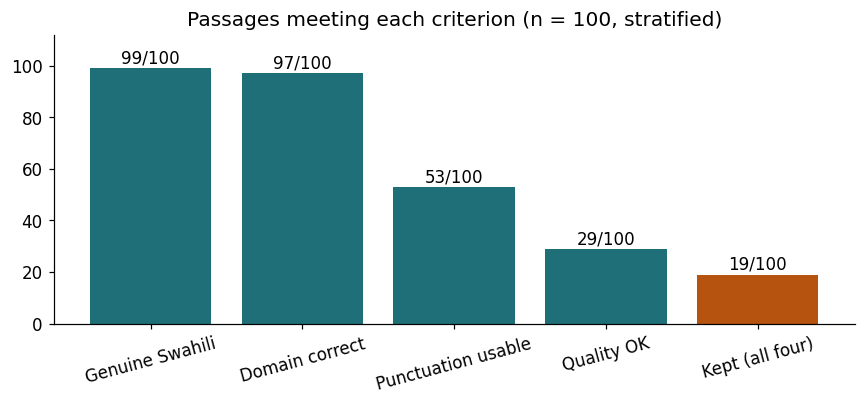

In [7]:
crit = [("Genuine Swahili", 99), ("Domain correct", 97), ("Punctuation usable", 53), ("Quality OK", 29), ("Kept (all four)", 19)]
fig, ax = plt.subplots()
ax.bar([c[0] for c in crit], [c[1] for c in crit], color=[TEAL, TEAL, TEAL, TEAL, ACCENT])
for i, c in enumerate(crit): ax.text(i, c[1] + 2, f"{c[1]}/100", ha="center")
ax.set_ylim(0, 112); ax.set_title("Passages meeting each criterion (n = 100, stratified)"); plt.xticks(rotation=15); plt.tight_layout(); plt.show()
print("AfriVoice: 0 of 54 kept (95% upper bound ~7%).  Everything else passing the rules: 17 of 24 kept (71%).")
print("Agreement with the AI screening: 31%.  The caption filter flagged 49 rows; Michael kept 1.")

## 4. Licences and the word target (capped at 200,000 per domain)

Capped totals  A: 11,128  B: 299,179  C: 399,876   (target 1,000,000; fallback 500,000)


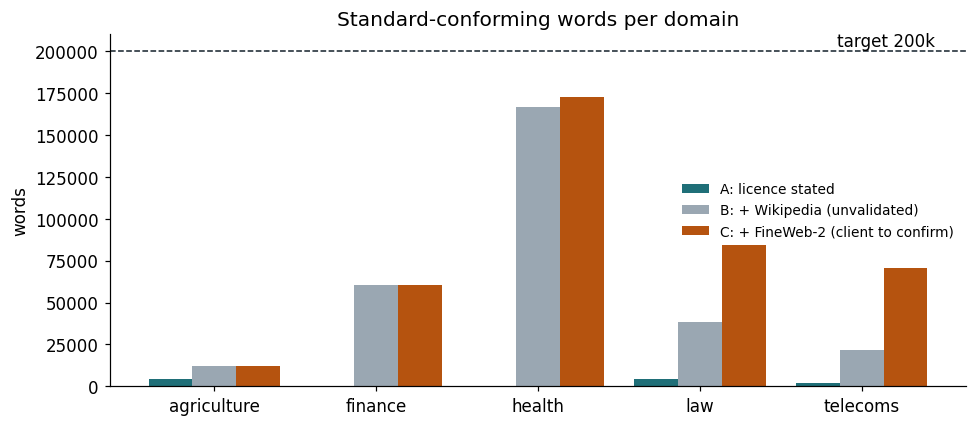

In [8]:
A, B, C = [4326, 278, 157, 4316, 2051], [11955, 60464, 166586, 38633, 21541], [11955, 60464, 172671, 84220, 70566]
import numpy as np
x = np.arange(len(D)); w = 0.27
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x - w, A, w, label="A: licence stated", color=TEAL); ax.bar(x, B, w, label="B: + Wikipedia (unvalidated)", color=GREY); ax.bar(x + w, C, w, label="C: + FineWeb-2 (client to confirm)", color=ACCENT)
ax.axhline(200000, color=INK, lw=1, ls="--"); ax.text(4.45, 203000, "target 200k", ha="right")
ax.set_xticks(x); ax.set_xticklabels(D); ax.set_ylabel("words"); ax.legend(frameon=False, fontsize=9); ax.set_title("Standard-conforming words per domain"); plt.tight_layout(); plt.show()
cap = lambda L: sum(min(v, 200000) for v in L)
print("Capped totals  A:", f"{cap(A):,}", " B:", f"{cap(B):,}", " C:", f"{cap(C):,}", "  (target 1,000,000; fallback 500,000)")

## 5. Seed corpus v1: at least 10,000 words per domain
Built from licence-clear text only (CC BY, CC BY-SA incl. Wikipedia, public-domain legislation) that passes the rules. **Not individually human-verified**; Michael's 19 kept passages are a separate gold file.

In [9]:
SEED = {
 "agriculture": {
  "passages": 152,
  "words": 10056,
  "from_documents": 152,
  "from_wikipedia": 0,
  "punct_marks": 900,
  "questions": 8,
  "available_clear_words": 206813
 },
 "finance": {
  "passages": 149,
  "words": 10009,
  "from_documents": 149,
  "from_wikipedia": 0,
  "punct_marks": 922,
  "questions": 15,
  "available_clear_words": 300200
 },
 "health": {
  "passages": 94,
  "words": 10030,
  "from_documents": 3,
  "from_wikipedia": 91,
  "punct_marks": 962,
  "questions": 0,
  "available_clear_words": 160221
 },
 "law": {
  "passages": 127,
  "words": 10018,
  "from_documents": 127,
  "from_wikipedia": 0,
  "punct_marks": 746,
  "questions": 0,
  "available_clear_words": 63025
 },
 "telecoms": {
  "passages": 152,
  "words": 10012,
  "from_documents": 152,
  "from_wikipedia": 0,
  "punct_marks": 924,
  "questions": 11,
  "available_clear_words": 140466
 }
}
GOLD = {"passages": 19, "words_by_domain": {"agriculture": 123, "health": 31, "telecoms": 3932, "law": 1751}, "total_words": 5837}

domain         words  passages  documents  wikipedia  punct marks  questions
agriculture   10,056       152        152          0          900          8
finance       10,009       149        149          0          922         15
health        10,030        94          3         91          962          0
law           10,018       127        127          0          746          0
telecoms      10,012       152        152          0          924         11

Gold (human-verified, Michael): 5837 words in 19 passages -> {'agriculture': 123, 'health': 31, 'telecoms': 3932, 'law': 1751}
Caveat: Wikipedia dominates finance, health, law and telecoms; its domain labels come from article categories plus a vocabulary filter and were not in the human sample.


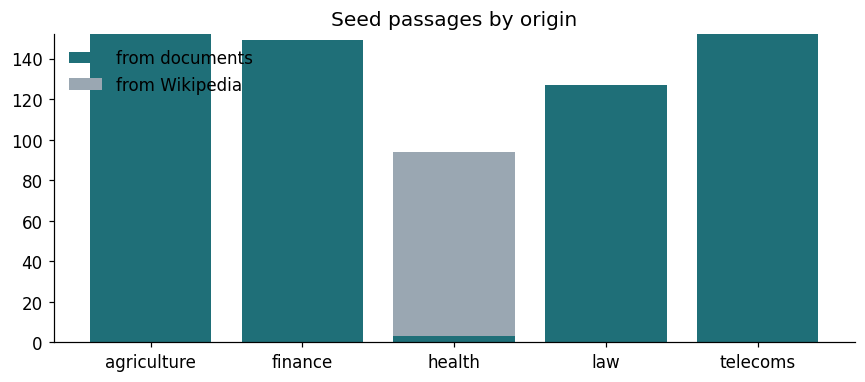

In [10]:
print(f"{'domain':12s} {'words':>7s} {'passages':>9s} {'documents':>10s} {'wikipedia':>10s} {'punct marks':>12s} {'questions':>10s}")
for d in D:
    s = SEED[d]; print(f"{d:12s} {s['words']:7,d} {s['passages']:9d} {s['from_documents']:10d} {s['from_wikipedia']:10d} {s['punct_marks']:12d} {s['questions']:10d}")
print()
print("Gold (human-verified, Michael):", GOLD["total_words"], "words in", GOLD["passages"], "passages ->", GOLD["words_by_domain"])
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.bar(D, [SEED[d]["from_documents"] for d in D], label="from documents", color=TEAL)
ax.bar(D, [SEED[d]["from_wikipedia"] for d in D], bottom=[SEED[d]["from_documents"] for d in D], label="from Wikipedia", color=GREY)
ax.set_title("Seed passages by origin"); ax.legend(frameon=False); plt.tight_layout(); plt.show()
print("Caveat: Wikipedia dominates finance, health, law and telecoms; its domain labels come from article categories plus a vocabulary filter and were not in the human sample.")

## 6. Word-level punctuation and capitalisation annotation (PnC labels)

In [11]:
LEAD = re.compile(r"^[(\[\"«]+")
TRAIL = re.compile(r"[,.;:?!…)\"\]»]+$")


def normalise(t):
    t = unicodedata.normalize("NFC", t)
    t = t.replace("’", "'").replace("‘", "'").replace("ʼ", "'").replace("“", '"').replace("”", '"')
    t = re.sub(r"\s+", " ", t).strip()
    return re.sub(r"\s+([,.;:?!])", r"\1", t)


def punct_label(post):
    for ch in post:
        if ch == ",": return "COMMA"
        if ch == "?": return "QUESTION"
        if ch == "!": return "EXCL"
        if ch in ";:…": return "OTHER"
        if ch == ".":
            return "OTHER" if "..." in post else "PERIOD"
    return "O"


def cap_label(w):
    letters = [c for c in w if c.isalpha()]
    if not letters: return "LOWER"
    if len(letters) > 1 and all(c.isupper() for c in letters): return "UPPER"
    if letters[0].isupper(): return "TITLE" if not any(c.isupper() for c in letters[1:]) else "MIXED"
    return "MIXED" if any(c.isupper() for c in letters) else "LOWER"


def annotate(text):
    toks = []
    for raw in normalise(text).split(" "):
        pre = LEAD.match(raw); pre = pre.group(0) if pre else ""
        rest = raw[len(pre):]
        post = TRAIL.search(rest); post = post.group(0) if post else ""
        core = rest[: len(rest) - len(post)]
        if not core:  # punctuation-only token: attach to previous token's post
            if toks: toks[-1]["post"] += " " + raw; toks[-1]["punct"] = punct_label(toks[-1]["post"]) if toks[-1]["punct"] == "O" else toks[-1]["punct"]
            continue
        toks.append({"pre": pre, "word": core, "post": post, "punct": punct_label(post), "cap": cap_label(core)})
    return toks


def rebuild(toks): return " ".join(t["pre"] + t["word"] + t["post"] for t in toks)

In [12]:
demo = "Mkulima alisema, \"Mvua ni nyingi mwaka huu.\" Je, tutavuna mahindi mengi? Ndiyo!"
toks = annotate(demo)
print("round trip ok:", rebuild(toks) == normalise(demo))
print(f"{'word':14s} {'punct':9s} {'cap':6s}")
for t in toks: print(f"{t['pre']+t['word']:14s} {t['punct']:9s} {t['cap']:6s}")

round trip ok: True
word           punct     cap   
Mkulima        O         TITLE 
alisema        COMMA     LOWER 
"Mvua          O         TITLE 
ni             O         LOWER 
nyingi         O         LOWER 
mwaka          O         LOWER 
huu            PERIOD    LOWER 
Je             COMMA     TITLE 
tutavuna       O         LOWER 
mahindi        O         LOWER 
mengi          QUESTION  LOWER 
Ndiyo          EXCL      TITLE 


Only 90 question-mark words in 438,996: this corpus (news, government, encyclopedia) barely teaches questions, which a spoken-QA project needs.


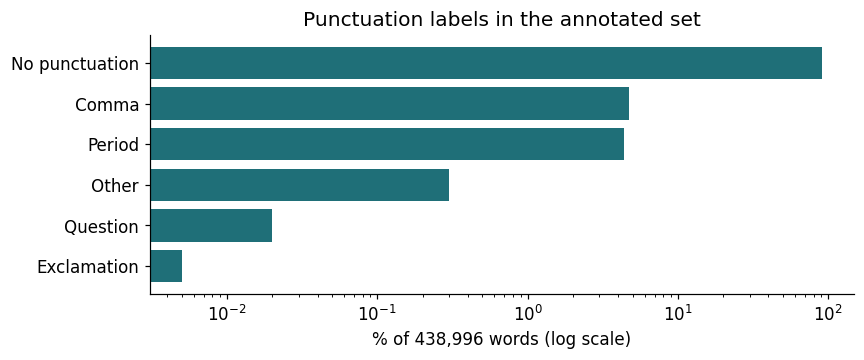

In [13]:
dist = {"No punctuation": 90.6, "Comma": 4.7, "Period": 4.4, "Other": 0.3, "Question": 0.02, "Exclamation": 0.005}
fig, ax = plt.subplots(figsize=(8, 3.4))
ax.barh(list(dist)[::-1], list(dist.values())[::-1], color=TEAL); ax.set_xscale("log"); ax.set_xlabel("% of 438,996 words (log scale)")
ax.set_title("Punctuation labels in the annotated set"); plt.tight_layout(); plt.show()
print("Only 90 question-mark words in 438,996: this corpus (news, government, encyclopedia) barely teaches questions, which a spoken-QA project needs.")

## 7. Domain classifier: retrained on seed v1, tested on human-reviewed passages
Same model spec (TF-IDF + logistic regression). Test = Michael's 97 reviewed passages whose domain he confirmed (17,118 words).

The weak-label model's 100% is inflated: 13 of 100 test passages have a near-duplicate in its training data and it learned keyword labels.
The seed-trained model has 1 near-duplicate; it is 57% on non-caption text and 75% on picture descriptions; law (statute text) and finance are the weakest classes.


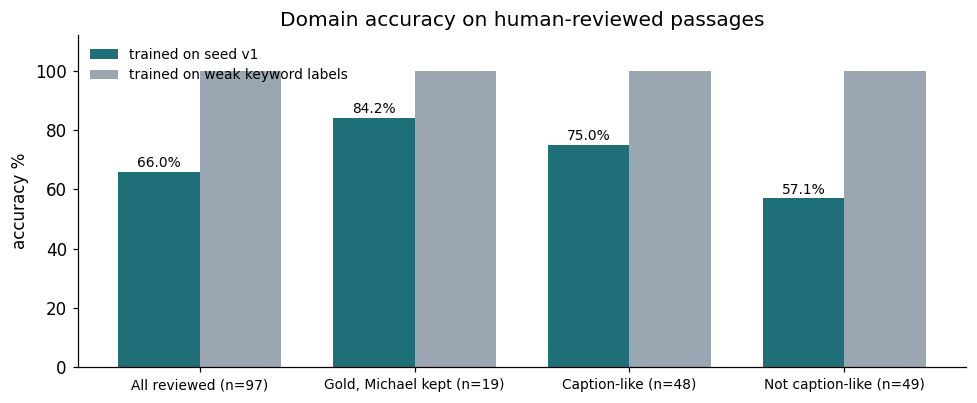

In [14]:
rows = [("All reviewed (n=97)", 66.0, 100), ("Gold, Michael kept (n=19)", 84.2, 100), ("Caption-like (n=48)", 75.0, 100), ("Not caption-like (n=49)", 57.1, 100)]
x = np.arange(len(rows)); w = 0.38
fig, ax = plt.subplots(figsize=(9, 3.8))
ax.bar(x - w/2, [r[1] for r in rows], w, label="trained on seed v1", color=TEAL); ax.bar(x + w/2, [r[2] for r in rows], w, label="trained on weak keyword labels", color=GREY)
for i, r in enumerate(rows): ax.text(i - w/2, r[1] + 1.5, f"{r[1]}%", ha="center", fontsize=9)
ax.set_xticks(x); ax.set_xticklabels([r[0] for r in rows], fontsize=9); ax.set_ylim(0, 112); ax.set_ylabel("accuracy %"); ax.legend(frameon=False, fontsize=9)
ax.set_title("Domain accuracy on human-reviewed passages"); plt.tight_layout(); plt.show()
print("The weak-label model's 100% is inflated: 13 of 100 test passages have a near-duplicate in its training data and it learned keyword labels.")
print("The seed-trained model has 1 near-duplicate; it is 57% on non-caption text and 75% on picture descriptions; law (statute text) and finance are the weakest classes.")

## 8. Word target by licence tier (latest counts)
Licence-clear = documents with a stated CC licence, Wikipedia (CC BY-SA), and FineWeb-2 (client said yes, written confirmation pending). News tier = Swahili news datasets whose card says CC BY 4.0 but whose newspaper text rights are not cleared. All text passes the same quality rules; none is human-verified; news finance text had glued sentences repaired.

Licence-clear total: 982,872  | news tier: 381,292  | 500k fallback met by licence-clear alone: True


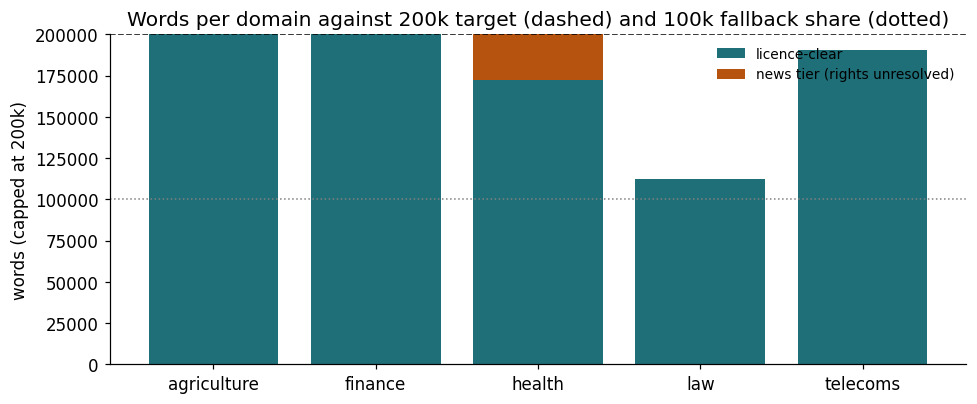

In [15]:
import json, os
T = json.load(open(os.path.join(DIR, "clear_words_now.json"))) if "DIR" in globals() else json.load(open("clear_words_now.json"))
doms = ["agriculture", "finance", "health", "law", "telecoms"]
cl = [min(T["licence_clear"][d], 200000) for d in doms]; nw = [min(T["news_tier"][d], max(0, 200000 - cl[i])) for i, d in enumerate(doms)]
fig, ax = plt.subplots(figsize=(9, 3.8)); x = np.arange(5)
ax.bar(x, cl, color=TEAL, label="licence-clear"); ax.bar(x, nw, bottom=cl, color=ACCENT, label="news tier (rights unresolved)")
ax.axhline(200000, color="black", lw=1, ls="--"); ax.axhline(100000, color="grey", lw=1, ls=":")
ax.set_xticks(x); ax.set_xticklabels(doms); ax.set_ylabel("words (capped at 200k)"); ax.legend(frameon=False, fontsize=9); ax.set_title("Words per domain against 200k target (dashed) and 100k fallback share (dotted)")
plt.tight_layout(); plt.show()
print("Licence-clear total:", f"{T['totals']['licence_clear']:,}", " | news tier:", f"{T['totals']['news_tier']:,}", " | 500k fallback met by licence-clear alone:", T['totals']['licence_clear'] >= 500000)

## 9. Next steps
| Item | Status |
|---|---|
| Second reviewer and a fluent-speaker check | pending |
| FineWeb-2 (ODC-By) | client said yes; written confirmation pending |
| Licensed agriculture and finance sources (non-caption text) | needed |
| Question-style text for PnC | needed |
| Model selection (Whisper, Gemma 3n, MMS; benchmark script ready) | next, with Rose |